In [ ]:
from keras.datasets import mnist

In [ ]:
(train_images, train_labels),(test_images , test_labels) = mnist.load_data()

In [ ]:
print(train_images.shape, "is the shape  of Train Images")

(60000, 28, 28) is the shape  of Train Images


In [ ]:
print(train_images)

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt

fig, axes = plt.subplots(5, 10, figsize=(12, 7), subplot_kw={'xticks': [], 'yticks': []})

for i, ax in enumerate(axes.flat):
    ax.imshow(train_images[i], cmap=plt.cm.gray_r)
    ax.text(0.45, 1.05, str(train_labels[i]), transform=ax.transAxes)

In [ ]:
from keras import models
from keras import layers

model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(layers.MaxPooling2D(2, 2))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D(2, 2))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.Flatten())

model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

In [ ]:
from tensorflow.keras.utils import to_categorical

test_image = test_images[11] # Save one image for making a prediction later
train_images = train_images.reshape(60000, 28, 28, 1)
train_images = train_images.astype('float32') / 255

test_images = test_images.reshape(10000, 28, 28, 1)
test_images = test_images.astype('float32') / 255

train_labels = to_categorical(train_labels)
test_labels = to_categorical(test_labels)

In [1]:
hist = model.fit(train_images, train_labels, validation_data=(test_images, test_labels), epochs=10, batch_size=64)

NameError: name 'model' is not defined

In [ ]:
scores = model.evaluate(test_images, test_labels,)
print('Accuracy: {:.1%}'.format(scores[1]))

313/313 [==============================] - 4s 13ms/step - loss: 0.0284 - accuracy: 0.9912
Accuracy: 99.1%


In [ ]:
plt.tick_params(axis='both', which='both', bottom=False, top=False, left=False, right=False, labelbottom=False, labelleft=False)
plt.imshow(test_image, cmap=plt.cm.gray_r)

In [ ]:
import numpy as np

test_image = test_images[11]
model.predict(np.array([test_image]))

array([[6.2630866e-06, 3.3318614e-14, 9.1492595e-17, 5.6008820e-16,
        3.1297230e-12, 1.6086683e-10, 9.9999368e-01, 4.2950125e-18,
        4.7264437e-10, 1.0899315e-14]], dtype=float32)

In [ ]:
predicted_class = np.argmax(model.predict(np.array([test_image])), axis=-1)[0]
print('Looks like a ' + str(predicted_class) + '!')

Looks like a 6!


In [ ]:
# Import necessary libraries and load the MNIST dataset
from keras.datasets import mnist
from keras import models, layers
from keras.utils import to_categorical

(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

# Reshape and normalize the image data
train_images = train_images.reshape(60000, 28, 28, 1)
train_images = train_images.astype('float32') / 255
test_images = test_images.reshape(10000, 28, 28, 1)
test_images = test_images.astype('float32') / 255

# One-hot encode the labels
train_labels = to_categorical(train_labels)
test_labels = to_categorical(test_labels)

# Create the CNN model
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(layers.MaxPooling2D(2, 2))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D(2, 2))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.Flatten())

model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
hist = model.fit(train_images, train_labels, validation_data=(test_images, test_labels), epochs=10, batch_size=64)

# Make a prediction on a single test image
import numpy as np
test_image = test_images[11]
predicted_class = np.argmax(model.predict(np.array([test_image])), axis=-1)[0]

print('Looks like a ' + str(predicted_class) + '!')


Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9455 - loss: 0.1819 - val_accuracy: 0.9839 - val_loss: 0.0499
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9837 - loss: 0.0522 - val_accuracy: 0.9874 - val_loss: 0.0423
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9882 - loss: 0.0360 - val_accuracy: 0.9855 - val_loss: 0.0489
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9911 - loss: 0.0283 - val_accuracy: 0.9895 - val_loss: 0.0318
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9929 - loss: 0.0221 - val_accuracy: 0.9900 - val_loss: 0.0307
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9945 - loss: 0.0174 - val_accuracy: 0.9912 - val_loss: 0.0287
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9950 - loss: 0.0151 - val_accuracy: 0.9919 - val_loss: 0.0283
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9958 - loss: 0.0125 - val_accuracy: 0

In [ ]:
# Enable GPU runtime in Google Colab:
# Go to "Runtime" > "Change runtime type" > Select "GPU" > Save

import time
from keras.datasets import mnist
from keras import models, layers
from keras.utils import to_categorical

# Load the MNIST dataset
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

# Reshape and normalize the image data
train_images = train_images.reshape(60000, 28, 28, 1)
train_images = train_images.astype('float32') / 255
test_images = test_images.reshape(10000, 28, 28, 1)
test_images = test_images.astype('float32') / 255

# One-hot encode the labels
train_labels = to_categorical(train_labels)
test_labels = to_categorical(test_labels)

# Create the CNN model
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(layers.MaxPooling2D(2, 2))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D(2, 2))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.Flatten())

model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model and measure the time taken
start_time = time.time()
hist = model.fit(train_images, train_labels, validation_data=(test_images, test_labels), epochs=10, batch_size=64)
end_time = time.time()

# Print the total time taken to train
total_time = end_time - start_time
print(f"Total time taken to train: {total_time:.2f} seconds")

# Make a prediction on a single test image
import numpy as np
test_image = test_images[11]
predicted_class = np.argmax(model.predict(np.array([test_image])), axis=-1)[0]

print('Looks like a ' + str(predicted_class) + '!')


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.8674 - loss: 0.4344 - val_accuracy: 0.9809 - val_loss: 0.0597
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9834 - loss: 0.0532 - val_accuracy: 0.9888 - val_loss: 0.0321
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9890 - loss: 0.0347 - val_accuracy: 0.9880 - val_loss: 0.0366
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9909 - loss: 0.0277 - val_accuracy: 0.9907 - val_loss: 0.0263
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9936 - loss: 0.0190 - val_accuracy: 0.9899 - val_loss: 0.0309
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9947 - loss: 0.0166 - val_accuracy: 0.9894 - val_loss: 0.0328
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9956 - loss: 0.0148 - val_accuracy: 0.9910 - val_loss: 0.0280
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9965 - loss: 0.0110 - val_accuracy: 

11490434/11490434 [==============================] - 1s 0us/step
Epoch 1/10
938/938 [==============================] - 13s 6ms/step - loss: 0.1704 - accuracy: 0.9488 - val_loss: 0.0464 - val_accuracy: 0.9853
Epoch 2/10
938/938 [==============================] - 5s 6ms/step - loss: 0.0456 - accuracy: 0.9860 - val_loss: 0.0372 - val_accuracy: 0.9864
Epoch 3/10
938/938 [==============================] - 5s 5ms/step - loss: 0.0337 - accuracy: 0.9895 - val_loss: 0.0314 - val_accuracy: 0.9905
Epoch 4/10
938/938 [==============================] - 5s 5ms/step - loss: 0.0265 - accuracy: 0.9918 - val_loss: 0.0314 - val_accuracy: 0.9910
Epoch 5/10
938/938 [==============================] - 5s 5ms/step - loss: 0.0213 - accuracy: 0.9934 - val_loss: 0.0275 - val_accuracy: 0.9915
Epoch 6/10
938/938 [==============================] - 5s 5ms/step - loss: 0.0171 - accuracy: 0.9946 - val_loss: 0.0250 - val_accuracy: 0.9929
Epoch 7/10
938/938 [==============================] - 5s 5ms/step - loss: 0.0148 -

Saving Screenshot 2024-06-25 123602.png to Screenshot 2024-06-25 123602.png
1/1 [==============================] - 0s 255ms/step


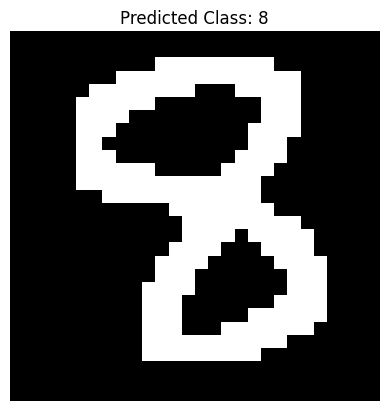

Predicted Class: 8


In [ ]:
import time
from keras.datasets import mnist
from keras import models, layers
from keras.utils import to_categorical
import numpy as np
import matplotlib.pyplot as plt

# Load the MNIST dataset
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

# Reshape and normalize the image data
train_images = train_images.reshape(60000, 28, 28, 1)
train_images = train_images.astype('float32') / 255
test_images = test_images.reshape(10000, 28, 28, 1)
test_images = test_images.astype('float32') / 255

# One-hot encode the labels
train_labels = to_categorical(train_labels)
test_labels = to_categorical(test_labels)

# Create the CNN model
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(layers.MaxPooling2D(2, 2))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D(2, 2))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model and measure the time taken
start_time = time.time()
hist = model.fit(train_images, train_labels, validation_data=(test_images, test_labels), epochs=10, batch_size=64)
end_time = time.time()

# Print the total time taken to train
total_time = end_time - start_time
print(f"Total time taken to train: {total_time:.2f} seconds")

import matplotlib.pyplot as plt
from keras.preprocessing import image
from google.colab import files
import io

def predict_digit(img_path):
    # Load the image
    img = image.load_img(img_path, target_size=(28, 28), color_mode='grayscale')
    img_array = image.img_to_array(img)
    img_array = img_array.reshape(1, 28, 28, 1)
    img_array = img_array.astype('float32') / 255

    # Predict the class
    predicted_class = np.argmax(model.predict(img_array), axis=-1)[0]

    # Display the image
    plt.imshow(img_array.reshape(28, 28), cmap='gray')
    plt.title(f'Predicted Class: {predicted_class}')
    plt.axis('off')
    plt.show()

    # Print the predicted class label
    print('Predicted Class: ' + str(predicted_class))

# Upload image
uploaded = files.upload()

# Predict for each uploaded image
for file_name in uploaded.keys():
    predict_digit(io.BytesIO(uploaded[file_name]))

In [ ]:
import matplotlib.pyplot as plt
from keras.preprocessing import image
from google.colab import files
import io

def predict_digit(img_path):
    # Load the image
    img = image.load_img(img_path, target_size=(28, 28), color_mode='grayscale')
    img_array = image.img_to_array(img)
    img_array = img_array.reshape(1, 28, 28, 1)
    img_array = img_array.astype('float32') / 255

    # Predict the class
    predicted_class = np.argmax(model.predict(img_array), axis=-1)[0]

    # Display the image
    plt.imshow(img_array.reshape(28, 28), cmap='gray')
    plt.title(f'Predicted Class: {predicted_class}')
    plt.axis('off')
    plt.show()

    # Print the predicted class label
    print('Predicted Class: ' + str(predicted_class))

# Upload image
uploaded = files.upload()

# Predict for each uploaded image
for file_name in uploaded.keys():
    predict_digit(io.BytesIO(uploaded[file_name]))

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

# Load and preprocess the Fashion MNIST dataset
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()
train_images = train_images.reshape((60000, 28, 28, 1)).astype('float32') / 255
test_images = test_images.reshape((10000, 28, 28, 1)).astype('float32') / 255
train_labels = to_categorical(train_labels)
test_labels = to_categorical(test_labels)

# Create a CNN model
model = Sequential()
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dense(10, activation='softmax'))

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(train_images, train_labels, epochs=5, batch_size=64, validation_split=0.2)

# Evaluate the model on test data
test_loss, test_acc = model.evaluate(test_images, test_labels)
print(f'Test accuracy: {test_acc * 100:.2f}%')

# Make predictions on a few test images
predictions = model.predict(test_images[:5])

# Visualize the test images and their predicted labels
plt.figure(figsize=(15, 5))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(test_images[i].reshape(28, 28), cmap='gray')
    predicted_label = tf.argmax(predictions[i]).numpy()
    true_label = tf.argmax(test_labels[i]).numpy()
    plt.title(f'Predicted: {predicted_label}\nTrue: {true_label}')
    plt.axis('off')
plt.show()


4422102/4422102 [==============================] - 1s 0us/step
Epoch 1/5
750/750 [==============================] - 19s 5ms/step - loss: 0.6080 - accuracy: 0.7772 - val_loss: 0.4242 - val_accuracy: 0.8461
Epoch 2/5
750/750 [==============================] - 4s 5ms/step - loss: 0.3818 - accuracy: 0.8622 - val_loss: 0.3443 - val_accuracy: 0.8740
Epoch 3/5
750/750 [==============================] - 3s 4ms/step - loss: 0.3250 - accuracy: 0.8822 - val_loss: 0.3163 - val_accuracy: 0.8860
Epoch 4/5
750/750 [==============================] - 4s 5ms/step - loss: 0.2912 - accuracy: 0.8936 - val_loss: 0.3105 - val_accuracy: 0.8904
Epoch 5/5
313/313 [==============================] - 1s 3ms/step - loss: 0.3110 - accuracy: 0.8885
Test accuracy: 88.85%
1/1 [==============================] - 0s 187ms/step


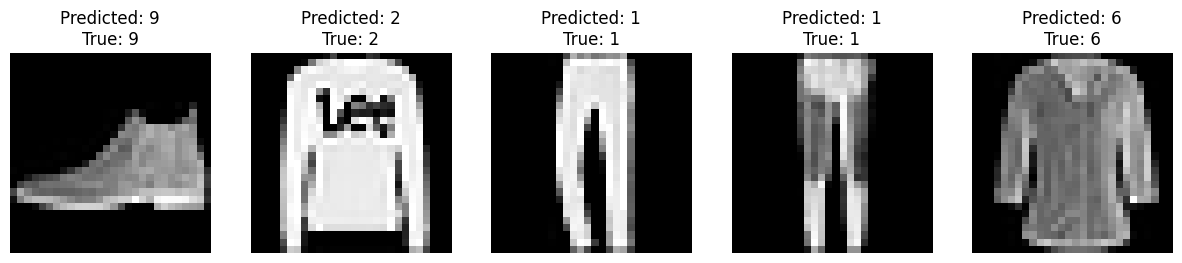

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

# Load and preprocess the Fashion MNIST dataset
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()
train_images = train_images.reshape((60000, 28, 28, 1)).astype('float32') / 255
test_images = test_images.reshape((10000, 28, 28, 1)).astype('float32') / 255
train_labels = to_categorical(train_labels)
test_labels = to_categorical(test_labels)

# Create a CNN model
model = Sequential()
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dense(10, activation='softmax'))

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(train_images, train_labels, epochs=5, batch_size=64, validation_split=0.2)

# Evaluate the model on test data
test_loss, test_acc = model.evaluate(test_images, test_labels)
print(f'Test accuracy: {test_acc * 100:.2f}%')

# Make predictions on a few test images
predictions = model.predict(test_images[:5])

# Visualize the test images and their predicted labels
plt.figure(figsize=(15, 5))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(test_images[i].reshape(28, 28), cmap='gray')
    predicted_label = tf.argmax(predictions[i]).numpy()
    true_label = tf.argmax(test_labels[i]).numpy()
    plt.title(f'Predicted: {predicted_label}\nTrue: {true_label}')
    plt.axis('off')
plt.show()


4422102/4422102 [==============================] - 1s 0us/step
Epoch 1/15
1875/1875 [==============================] - 39s 14ms/step - loss: 1.0871 - accuracy: 0.5979 - val_loss: 0.6776 - val_accuracy: 0.7346
Epoch 2/15
1875/1875 [==============================] - 29s 15ms/step - loss: 0.7894 - accuracy: 0.7043 - val_loss: 0.6074 - val_accuracy: 0.7723
Epoch 3/15
1875/1875 [==============================] - 27s 14ms/step - loss: 0.7009 - accuracy: 0.7384 - val_loss: 0.6128 - val_accuracy: 0.7695
Epoch 4/15
1875/1875 [==============================] - 28s 15ms/step - loss: 0.6487 - accuracy: 0.7582 - val_loss: 0.5782 - val_accuracy: 0.7897
Epoch 5/15
1875/1875 [==============================] - 27s 14ms/step - loss: 0.6090 - accuracy: 0.7738 - val_loss: 0.5968 - val_accuracy: 0.7751
Epoch 6/15
1875/1875 [==============================] - 27s 14ms/step - loss: 0.5811 - accuracy: 0.7857 - val_loss: 0.5116 - val_accuracy: 0.8138
Epoch 7/15
1875/1875 [==============================] - 27s 1

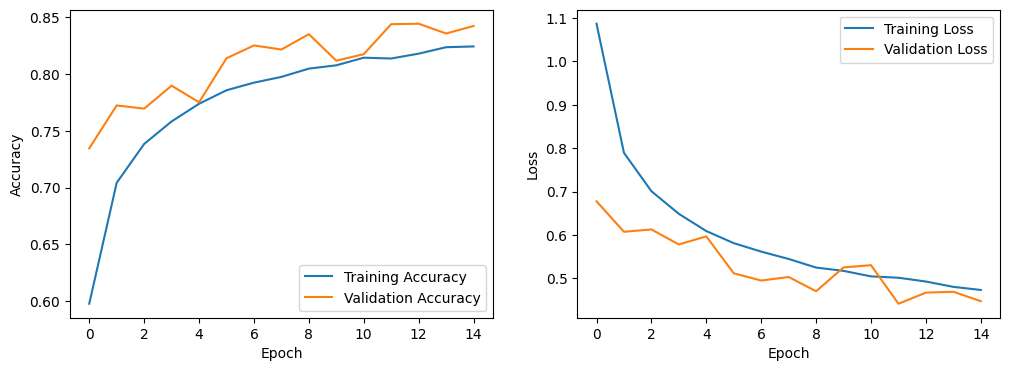

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()
train_images = train_images.reshape((60000, 28, 28, 1)).astype('float32') / 255
test_images = test_images.reshape((10000, 28, 28, 1)).astype('float32') / 255
train_labels = tf.keras.utils.to_categorical(train_labels)
test_labels = tf.keras.utils.to_categorical(test_labels)

datagen = ImageDataGenerator(
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

model = Sequential()
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dense(10, activation='softmax'))

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

batch_size = 32
epochs = 15
history = model.fit(datagen.flow(train_images, train_labels, batch_size=batch_size),
                    steps_per_epoch=len(train_images) // batch_size,
                    epochs=epochs,
                    validation_data=(test_images, test_labels))

test_loss, test_acc = model.evaluate(test_images, test_labels)
print(f'Test accuracy: {test_acc * 100:.2f}%')

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')

plt.show()


In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.optimizers import Adam





In [ ]:
dataset_name = 'tf_flowers'
(raw_train, raw_validation, raw_test), metadata = tfds.load(
    dataset_name,
    split=['train[:80%]', 'train[80%:90%]', 'train[90%:]'],
    with_info=True,
    as_supervised=True
)


Dl Completed...:   0%|          | 0/5 [00:00<?, ? file/s]

Dataset tf_flowers downloaded and prepared to /root/tensorflow_datasets/tf_flowers/3.0.1. Subsequent calls will reuse this data.


In [ ]:
def preprocess_image(image, label):
    image = tf.image.resize(image, (224, 224))
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, max_delta=0.1)
    image = tf.image.random_saturation(image, lower=0.5, upper=1.5)
    image = tf.image.random_hue(image, max_delta=0.2)
    image = tf.image.random_contrast(image, lower=0.5, upper=1.5)
    image = tf.clip_by_value(image, 0.0, 1.0)  # Ensure pixel values are in [0, 1]
    return image, label

batch_size = 32
train_data = raw_train.map(preprocess_image).batch(batch_size).shuffle(buffer_size=1000)
validation_data = raw_validation.map(preprocess_image).batch(batch_size)
